In [1]:
import numpy as np
import pandas as pd
#import umap
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq

#from muon import prot as pt
from sklearn import preprocessing
import os
import sys
sys.path.append('../phenotyping/')
from collections import defaultdict
from tqdm import tqdm
import seaborn as sns
input_dir = 'pre_processed_files/'
output_fig = '../figures'
def strip_extension(self):
    '''strip the file extension from a pd.Series of file names'''
    return self.apply(lambda x: os.path.splitext(x)[0])

from phenotyping_utils import generate_anndata_from_ark_analysis
# Add the method to the Pandas Series class
pd.Series.strip_extension = strip_extension
%matplotlib inline

In [2]:
!ls 

assign_cell_types.ipynb			    fiber_segmentation_processed_data
Carboplatin_acquisition_ID.csv		    non_spatial.ipynb
cell_neighbors_analysis.ipynb		    prova.png
data					    __pycache__
distance_distribution.pkl		    spatial.ipynb
example_neighborhood_analysis_script.ipynb  visualise_cell_annotation.ipynb
fiber_segmentation.ipynb


In [6]:
adata = generate_anndata_from_ark_analysis(cell_table_path='../../segmentation/cell_table_Denoised/cell_table_size_normalized_cell_labels.csv')

/home/giuseppe/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


read intensities ( protein level per cell)

N. of cells by experiments, for the rest of the analysis, we discard samples with less than a 1000 cells

few fovs have all cell types

In [ ]:
a = adata.obs[['Leap_ID','SAMPLE_TYPE_(CORE/RESECTION)','Response']]
a.drop_duplicates().Response.value_counts()
#a.drop_duplicates()['SAMPLE_TYPE_(CORE/RESECTION)'].value_counts()

## Inspecting the cell annotation

In [7]:
core = adata[adata.obs['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE'].copy()

take picture of a specific file, do not mix ROIs together

/home/giuseppe/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1294: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/giuseppe/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1294: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/giuseppe/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1294: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/giuseppe/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1294: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/giuseppe/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1294: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home

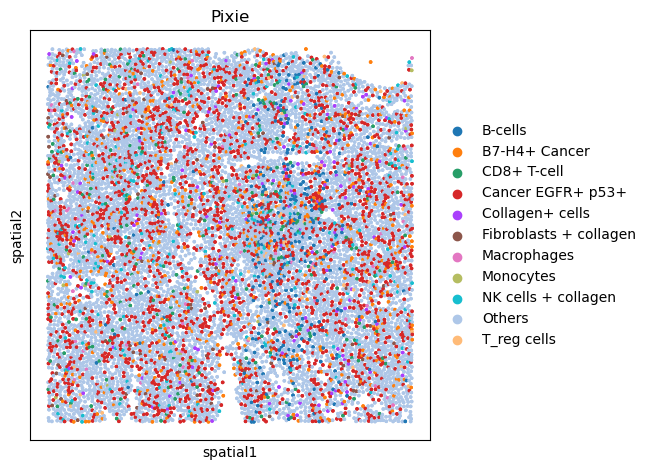

In [34]:
ax = sq.pl.spatial_scatter(adata[adata.obs.acquisition_ID =='Leap076_1'], shape=None, color="Pixie", size=10,return_ax= True)
plt.tight_layout()
#plt.savefig(output_fig+'/spatial/spatial_Leap076_1.png')

In [424]:
output_fig
!ls ../

AnnoSpat			 pixie
cell_type_knowledge_graph.ipynb  process_response_status.py
cross_slide_exploration.ipynb	 reformatting_all_files.ipynb
data				 reformatting_all_files.py
deepcell			 spatial_analysis
figures				 tot_intensity_per_acquisition.pkl
imcsegpipe


In [42]:
adata.obs.acquisition_ID.value_counts()

acquisition_ID
Leap042_6    14895
Leap043_6    12623
Leap086_5    12313
Leap076_1    11578
Leap042_2    11383
             ...  
Leap031_4       18
Leap021_2       16
Leap029_3        5
Leap024_4        1
Leap025_4        1
Name: count, Length: 788, dtype: int64

Pixie
Others                    7109
Cancer EGFR+ p53+         2052
B7-H4+ Cancer              536
B-cells                    316
CD8+ T-cell                235
NK cells + collagen        227
Collagen+ cells            148
Fibroblasts + collagen     108
T_reg cells                 66
Macrophages                 52
Monocytes                   29
Name: count, dtype: int64

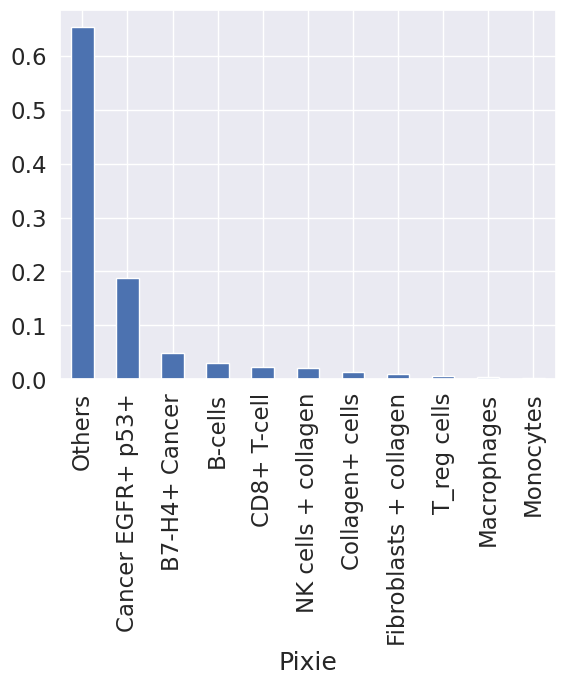

In [9]:
leap_file = 'Leap076_1'
adata[adata.obs.acquisition_ID ==leap_file].obs.Pixie.value_counts(normalize = True).plot(kind = 'bar')
#len(adata[adata.obs.filename =='Leap002_005'].obs.leiden.value_counts())
adata[adata.obs.acquisition_ID ==leap_file].obs.Pixie.value_counts()

In [44]:
adata.obs.Pixie.value_counts(normalize = True)

Pixie
B7-H4+ cancer               0.180375
Immune cell                 0.083626
Naive T-cell                0.061410
NK cell / B7-H4 cancer      0.059150
Neutrophil / B7-H4          0.058591
NK / Immune                 0.056054
Mem CD8+ T-cell             0.053665
Int Monocyte                0.051359
Neutrophil & Monocyte       0.045300
NonCI Monocyte              0.044567
Denditric                   0.041915
Mem T-cell                  0.035720
Mem B-cell                  0.035362
Fibroblast                  0.032895
NK T cell                   0.029284
Reg T-cell                  0.024691
Immune cell / Fibroblast    0.024666
Cancer / NK                 0.023690
Endothelial cell            0.017259
Macrophage                  0.017149
Activated T-cell            0.014702
CD163+ MAC                  0.008571
Name: proportion, dtype: float64

/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_utils.py:141: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[key]):


  0%|          | 0/1000 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_utils.py:141: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[key]):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/pl/_utils.py:556: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  row_labels = adata.obs[key][row_order]


Text(0.5, 0, 'Cell type')

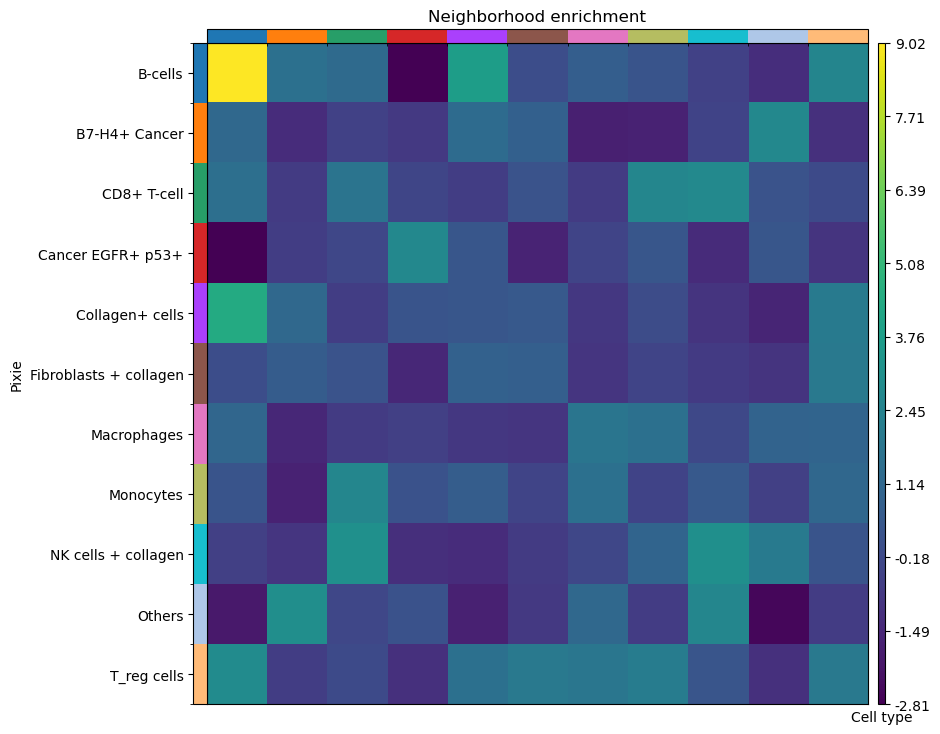

In [24]:
sub_adata = adata[adata.obs.acquisition_ID == 'Leap076_1'].copy()
#sub_adata = adata
sq.gr.spatial_neighbors(sub_adata,coord_type='grid')
sq.gr.nhood_enrichment(sub_adata, cluster_key='Pixie')
A = sub_adata.uns['Pixie_nhood_enrichment']['zscore']
#sq.pl.nhood_enrichment(adata, cluster_key='AnnoSpat',save='/enrichment.png')
sq.pl.nhood_enrichment(sub_adata, cluster_key='Pixie')
plt.xlabel('Cell type')


In [48]:
a = sub_adata.uns['Pixie_nhood_enrichment']['zscore']
b = sub_adata.obsp['spatial_distances']
b - b.T,b

(<14895x14895 sparse matrix of type '<class 'numpy.float64'>'
 	with 6198 stored elements in Compressed Sparse Row format>,
 <14895x14895 sparse matrix of type '<class 'numpy.float64'>'
 	with 73311 stored elements in Compressed Sparse Row format>)

In [49]:
a = np.array(sub_adata.obs['Pixie'].cat.categories)
pd.DataFrame(A,index=a,columns=a).shape

(18, 18)

In [7]:
#extract the list of labels in common to all the acquisitions
labels_list = adata.obs['Pixie'].unique()
#labels_list[labels_list.value_counts()==len(adata.obs.acquisition_ID.unique())]
#cond = labels_list.value_counts()==len(adata.obs.acquisition_ID.unique())
#labels_list = cond[cond].index

For every acquisition_ID, the neighbourhood enrichment is computed. To compute the average,  for every pair of labels, the z-score are added and divided by the number of fovs that contains the 2 labels.

In [8]:
#labels_list = adata.obs.Pixie.unique()
enrich_matrix = pd.DataFrame(0,index = labels_list,columns=labels_list)
denominator =  pd.DataFrame(0,index = labels_list,columns=labels_list)
for ID in adata.obs.acquisition_ID.unique():
    sub_adata = adata[adata.obs.acquisition_ID==ID]#select one acquisition
    sq.gr.spatial_neighbors(sub_adata,coord_type='grid')
    sq.gr.nhood_enrichment(sub_adata, cluster_key='Pixie')
    A = sub_adata.uns['Pixie_nhood_enrichment']['zscore']
    a = np.array(sub_adata.obs['Pixie'].cat.categories)#label list
    enrich_matrix.loc[a,a]+=pd.DataFrame(A,index=a,columns=a)

    #print(np.diag(enrich_matrix))
    denominator.loc[a,a]+=1
    

/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_utils.py:198: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data
/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_utils.py:141: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[key]):


  0%|          | 0/1000 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_nhood.py:188: RuntimeWarning: invalid value encountered in divide
  zscore = (count - perms.mean(axis=0)) / perms.std(axis=0)
/tmp/ipykernel_566585/3016421301.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[        nan -0.07088812 -0.1505183  -0.26243542  0.50829961 -0.14998296
 -0.22454436 -0.8356065  -0.594803   -0.20960938 -0.31181982]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  enrich_matrix.loc[a,a]+=pd.DataFrame(A,index=a,columns=a)
/tmp/ipykernel_566585/3016421301.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.07088812         nan  8.71475576  0.17095468  1.33622423 -0.0776931
 -0.19324699 -0.59297886 -0.39597276 -0.14998296 -0.17920233]' has dtype incompatible with int64, please explicitly cast to a compatible d

  0%|          | 0/1000 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_nhood.py:188: RuntimeWarning: invalid value encountered in divide
  zscore = (count - perms.mean(axis=0)) / perms.std(axis=0)
/tmp/ipykernel_566585/3016421301.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 3.02954192 -0.23952223 -0.44825826  4.11112195 -0.7501249   9.71696663
 -0.11915865  0.62034081 -0.24019223 -8.21072469  1.2151409  -0.17281816
 -0.1505183  -0.56831261 14.51019241]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  enrich_matrix.loc[a,a]+=pd.DataFrame(A,index=a,columns=a)
/tmp/ipykernel_566585/3016421301.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.24371469 -0.08396038 -0.65710055 -0.64465889 -0.40530917  7.18827743
 -0.0548546  -0.39463317 -0.10050378 -4.15356799 -0.76777079 -0.0548546
 -0.08980265 -0.

...

/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_nhood.py:188: RuntimeWarning: invalid value encountered in divide
  zscore = (count - perms.mean(axis=0)) / perms.std(axis=0)
/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_utils.py:198: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data
/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_utils.py:141: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[key]):


  0%|          | 0/1000 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_nhood.py:188: RuntimeWarning: invalid value encountered in divide
  zscore = (count - perms.mean(axis=0)) / perms.std(axis=0)
/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_utils.py:198: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data
/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_utils.py:141: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[key]):


  0%|          | 0/1000 [00:00<?, ?/s]

ValueError: Expected n_neighbors <= n_samples,  but n_samples = 1, n_neighbors = 7

# Spatial Analysis
### neighbours

In [54]:
pd.DataFrame(A,index=a,columns=a)
np.max(A-A.T)

1.2998028490476878

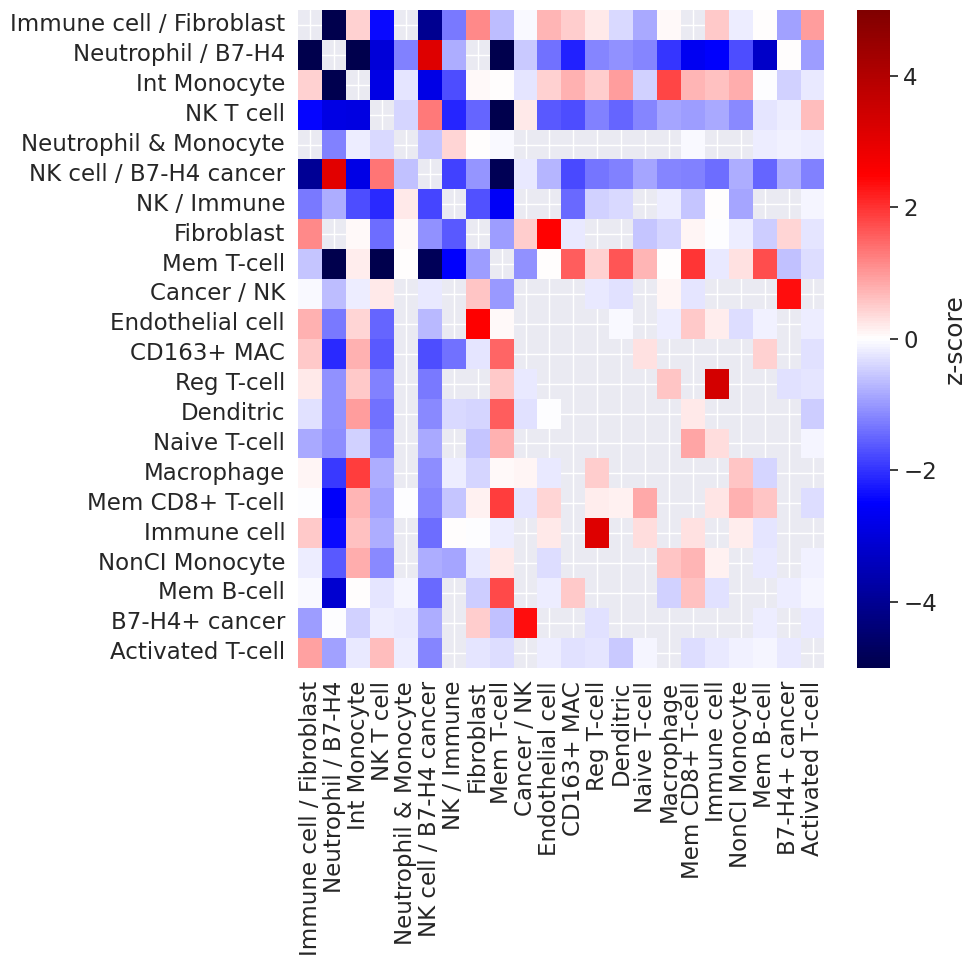

In [9]:
plt.figure(figsize = (10,10))
sns.set(font_scale=1.5)
A = enrich_matrix/denominator
v = A.loc[A.index,A.index].values
np.fill_diagonal(v,np.NaN)
sns.heatmap(pd.DataFrame(v,columns= A.index,index=A.index ),cmap='seismic',xticklabels=True,vmin=-5,vmax = 5,cbar_kws={'label': 'z-score'})
plt.tight_layout()
#plt.savefig(output_fig+'/spatial/enrichment.png')


In [26]:
output_fig+'/spatial/enrichment.png'

'../figures/spatial/enrichment.png'

In [65]:
adata.obs.Pixie.value_counts(normalize = True)

Pixie
B7-H4+ cancer               0.180375
Immune cell                 0.083626
Naive T-cell                0.061410
NK cell / B7-H4 cancer      0.059150
Neutrophil / B7-H4          0.058591
NK / Immune                 0.056054
Mem CD8+ T-cell             0.053665
Int Monocyte                0.051359
Neutrophil & Monocyte       0.045300
NonCI Monocyte              0.044567
Denditric                   0.041915
Mem T-cell                  0.035720
Mem B-cell                  0.035362
Fibroblast                  0.032895
NK T cell                   0.029284
Reg T-cell                  0.024691
Immune cell / Fibroblast    0.024666
Cancer / NK                 0.023690
Endothelial cell            0.017259
Macrophage                  0.017149
Activated T-cell            0.014702
CD163+ MAC                  0.008571
Name: proportion, dtype: float64

<Axes: xlabel='Pixie'>

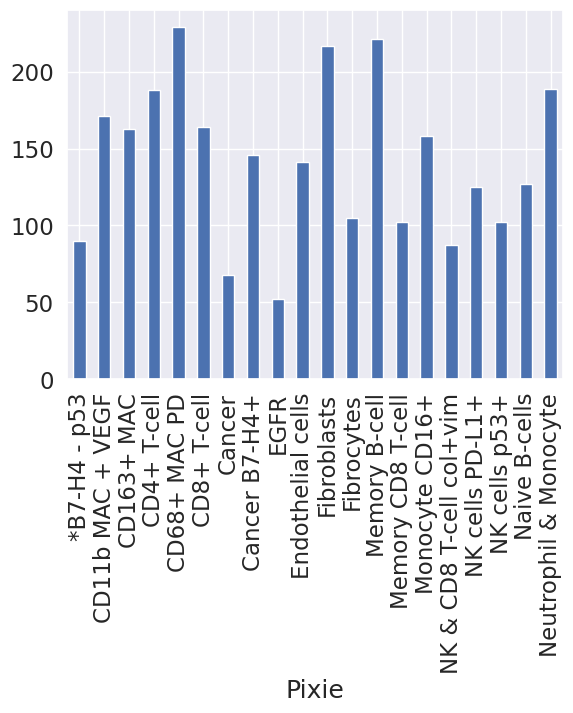

In [259]:
adata.obs[['Pixie','acquisition_ID']]
adata.obs.groupby('Pixie')['acquisition_ID'].nunique().plot(kind = 'bar')

In [64]:
'''
for k,v in adata.obs.groupby('acquisition_ID')['Pixie'].groups.items():
    adata.obs.loc[v]['Pixie'].value_counts().plot(kind = 'bar')
    plt.title(k)
    plt.figure()
#adata.obs[['acquisition_ID','Pixie']]#.pivot(index ='acquisition_ID',columns='Pixie')
'''

"\nfor k,v in adata.obs.groupby('acquisition_ID')['Pixie'].groups.items():\n    adata.obs.loc[v]['Pixie'].value_counts().plot(kind = 'bar')\n    plt.title(k)\n    plt.figure()\n#adata.obs[['acquisition_ID','Pixie']]#.pivot(index ='acquisition_ID',columns='Pixie')\n"

# statistics of enrichment for non responder
after treatment


In [19]:
pd.Series(adata.obs['Pixie'].cat.categories).sort_values()

0             Activated T-cell
1                B7-H4+ cancer
2                   CD163+ MAC
3                  Cancer / NK
4                    Denditric
5             Endothelial cell
6                   Fibroblast
7                  Immune cell
8     Immune cell / Fibroblast
9                 Int Monocyte
10                  Macrophage
11                  Mem B-cell
12             Mem CD8+ T-cell
13                  Mem T-cell
14                 NK / Immune
15                   NK T cell
16      NK cell / B7-H4 cancer
17                Naive T-cell
18       Neutrophil & Monocyte
19          Neutrophil / B7-H4
20              NonCI Monocyte
21                  Reg T-cell
dtype: object

In [50]:
response_acq_ID = pd.DataFrame([*core.obs[['Response','acquisition_ID']].value_counts().index],columns = ['Response','acquisition_ID'])
for response_status,index in response_acq_ID.groupby('Response').groups.items():
    pass
response_acq_ID.loc[index].acquisition_ID

0      Leap042_6
1      Leap086_5
3      Leap043_6
4      Leap086_6
9      Leap042_3
         ...    
459    Leap009_9
461    Leap087_1
462    Leap008_8
465    Leap009_2
466    Leap010_2
Name: acquisition_ID, Length: 238, dtype: object

In [208]:
dic = defaultdict(list)
key0 = 'B7-H4+ cancer'#'CD163+ MAC'#'Fibroblast'#'Cancer'#'B7-H4+ Cancer' #

'''
types_to_inspect = ['Activated T-cell', 'B7-H4+ cancer', 'CD163+ MAC', 'Cancer / NK',
       'Denditric', 'Endothelial cell', 'Fibroblast', 'Immune cell',
       'Immune cell / Fibroblast', 'Int Monocyte', 'Macrophage',
       'Mem B-cell', 'Mem CD8+ T-cell', 'Mem T-cell', 'NK / Immune',
       'NK T cell', 'NK cell / B7-H4 cancer', 'Naive T-cell',
       'Neutrophil & Monocyte', 'Neutrophil / B7-H4', 'NonCI Monocyte',
       'Reg T-cell']
'''
types_to_inspect = np.array(adata.obs['Pixie'].cat.categories)
def distance_dictionary(key0,adata,types_to_inspect=None,by_response_status = True):
    interval = np.linspace(0,1200,30)
    def make_dic(adata,acquisition_list,key0,types_to_inspect):
        dic =defaultdict(list)
        for ID in  tqdm(acquisition_list):
            sub_adata = adata[adata.obs.acquisition_ID==ID].copy()
            a = np.array(sub_adata.obs['Pixie'].cat.categories)#label list

            if ((key0 in a)& np.isin(types_to_inspect,a).any()): 
                #if there is at least a cell to inspect
                sq.gr.co_occurrence(sub_adata, cluster_key="Pixie",n_splits=1,interval=interval,show_progress_bar=False)
                x = sub_adata.uns['Pixie_co_occurrence']['interval'][1:]
                cooccur = np.squeeze(sub_adata.uns['Pixie_co_occurrence']['occ'][np.arange(len(a))[a==key0]])
                for key in types_to_inspect:
                    if (key in a):
                        y = np.squeeze(cooccur[a ==key])
                        dic[key]+=[y]

        return dic

    if types_to_inspect is None:
        types_to_inspect = adata.obs.Pixie.unique()
   

    if by_response_status == True:
        a = {}
        response_acq_ID = pd.DataFrame([*adata.obs[['Response','acquisition_ID']].value_counts().index],columns = ['Response','acquisition_ID'])
        for response_status,index in response_acq_ID.groupby('Response').groups.items():
            a[response_status] = make_dic(adata,response_acq_ID.loc[index].acquisition_ID,key0,types_to_inspect)
        return a['pCR'],a['Non-Responder'],interval
    else:
        return make_dic(adata,adata.obs.acquisition_ID.unique(),key0,types_to_inspect),interval
core = adata[adata.obs['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE']


Line below generates a nested structures of dictionary. After this cell, you can load from the disk


**It takes ages, do not run the cell below!** load from disk instead

In [ ]:
resection = adata[adata.obs['SAMPLE_TYPE_(CORE/RESECTION)']=='RESECTION']
dic = {}
for key0 in types_to_inspect:
    dic_pCR_temp,dic_nR_temp,x =  distance_dictionary(key0,core,types_to_inspect,by_response_status = True)
    dic_resection_temp,x =  distance_dictionary(key0,resection,types_to_inspect,by_response_status = False)
    dic_pCR[key0] = dic_pCR_temp
    dic_nR[key0] = dic_nR_temp    
    dic_resection[key0] = dic_resection_temp
#dic,x =  distance_dictionary(key0,adata,types_to_inspect,by_response_status = False)

  0%|                                                   | 0/232 [00:00<?, ?it/s]/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_utils.py:141: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[key]):
  2%|▋                                          | 4/232 [00:06<03:18,  1.15it/s]/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_utils.py:141: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[key]):
  3%|█▎                                         | 7/232 [00:10<03:57,  1.05s/it]/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_utils.py:141: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_

In [4]:
import pickle 
with open('distance_distribution.pkl', 'wb') as f:
    pickle.dump({'resection':dic_resection,'pCR':dic_pCR,'non_responder':dic_nR}, f)
dic_resection.keys()

PermissionError: [Errno 13] Permission denied: 'distance_distribution.pkl'

In [3]:
with open('distance_distribution.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)

NameError: name 'pickle' is not defined

In [3]:
dic_resection = loaded_dict['resection']
dic_pCR = loaded_dict['pCR']
dic_nR = loaded_dict['non_responder']

key0 is the cell type we compute the 

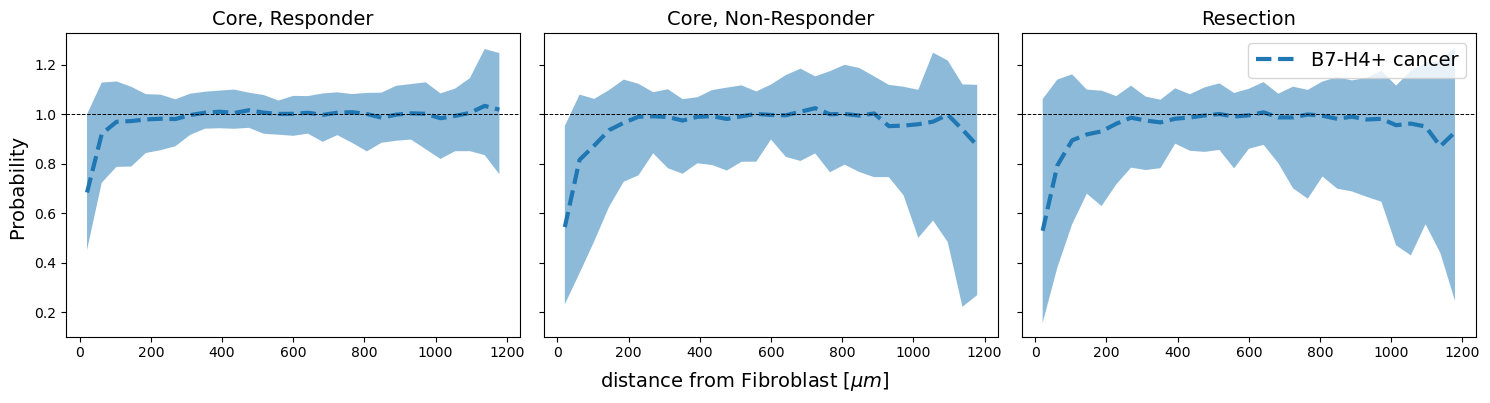

In [229]:
key0 = 'Fibroblast'#'CD163+ MAC'
dic_resection_key0 = dic_resection[key0]
dic_pCR_key0  = dic_pCR[key0]
dic_nR_key0 = dic_nR[key0]
f,axs = plt.subplots(ncols=3,nrows=1,figsize = (15,4),sharey=True)
for key in  ['B7-H4+ cancer']:
    #'CD163+ MAC''Activated T-cell'
    #responders
    axs[0].plot((x[1:]+x[:-1])/2,np.nanmedian(dic_pCR_key0[key],axis = 0),label = key,ls = '--',lw = 3)
    q75, q25 = np.nanpercentile(dic_pCR_key0[key], [75 ,25],axis = 0)
    axs[0].fill_between((x[1:]+x[:-1])/2,q75,q25,alpha = 0.5)
    axs[0].set_title('Core, Responder',fontsize = 14)
    axs[1].plot((x[1:]+x[:-1])/2,np.nanmedian(dic_nR_key0[key],axis = 0),label = key,ls = '--',lw = 3)
    q75, q25 = np.nanpercentile(dic_nR_key0[key], [75 ,25],axis = 0)
    axs[1].fill_between((x[1:]+x[:-1])/2,q75,q25,alpha = 0.5)
    axs[1].set_title('Core, Non-Responder',fontsize = 14)
    axs[2].plot((x[1:]+x[:-1])/2,np.nanmedian(dic_resection_key0[key],axis = 0),label = key,ls = '--',lw = 3)
    q75, q25 = np.nanpercentile(dic_resection_key0[key], [75 ,25],axis = 0)
    axs[2].fill_between((x[1:]+x[:-1])/2,q75,q25,alpha = 0.5)
    axs[2].set_title('Resection',fontsize = 14)
    axs[0].axhline(1,ls = '--',c = 'k',lw = 0.7)
    axs[1].axhline(1,ls = '--',c = 'k',lw = 0.7)
    axs[2].axhline(1,ls = '--',c = 'k',lw = 0.7)
plt.xlabel(' ')
plt.legend(loc = 'lower right')
plt.tight_layout()
#axs[0].set_ylabel('$\\frac{P(X|\mathrm{CD163^+MAC})}{P(X)}$',fontsize = 16)
axs[0].set_ylabel('Probability ',fontsize = 14)

f.text(0.5, 0.02, 'distance from '+key0+' [$\mu m$]', ha='center',fontsize = 14)
#f.text(0.5, 0.02, 'distance from $\mathrm{CD163^+MAC}$ [$\mu m$]', ha='center',fontsize = 14)
#f.text(0.5, 0.96,'$P(X|\mathrm{CD163})/P(X)$',fontsize = 14)

plt.legend(fontsize = 14)
plt.tight_layout()
#plt.savefig(output_fig+'/spatial/co_occurrence_CD163Mac.png')
plt.show()

In [148]:
axs[0].axhline()

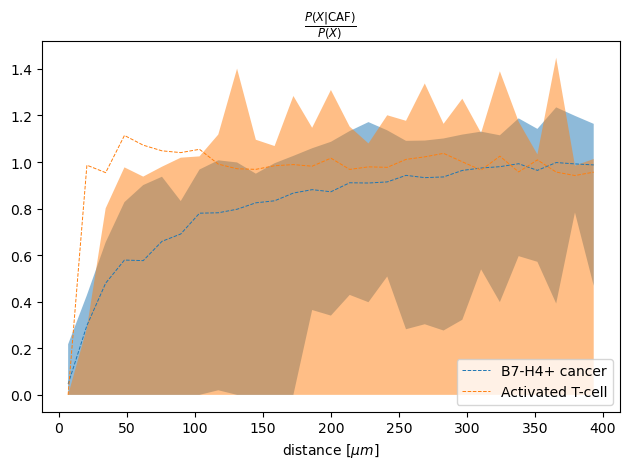

In [94]:
for key in ['B7-H4+ cancer','Activated T-cell']:#['Macrophage','B7-H4+ cancer']:
    plt.plot((x[1:]+x[:-1])/2,np.nanmedian(dic_resection[key],axis = 0),label = key,ls = '--',lw = 0.7)
    q75, q25 = np.nanpercentile(dic_nR[key], [75 ,25],axis = 0)
    plt.fill_between((x[1:]+x[:-1])/2,q75,q25,alpha = 0.5)

plt.xlabel('distance [$\mu m$]')
plt.title('$\\frac{P(X|\mathrm{CAF})}{P(X)}$')
plt.legend(loc = 'lower right')
plt.tight_layout()


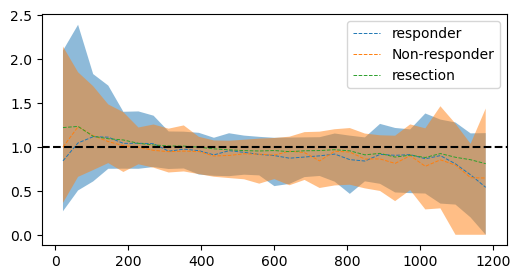

In [156]:
plt.figure(figsize = (6,3))
key = 'Fibroblast'#'Activated T-cell'
plt.plot((x[1:]+x[:-1])/2,np.nanmedian(dic_pCR[key],axis = 0),ls = '--',lw = 0.7,label = 'responder')
q75, q25 = np.nanpercentile(dic_pCR[key], [75 ,25],axis = 0)
plt.fill_between((x[1:]+x[:-1])/2,q75,q25,alpha = 0.5)
plt.plot((x[1:]+x[:-1])/2,np.nanmedian(dic_nR[key],axis = 0),ls = '--',lw = 0.7,label = 'Non-responder')
q75, q25 = np.nanpercentile(dic_nR[key], [75 ,25],axis = 0)
plt.fill_between((x[1:]+x[:-1])/2,q75,q25,alpha = 0.5)
plt.plot((x[1:]+x[:-1])/2,np.nanmedian(dic_resection[key],axis = 0),ls = '--',lw = 0.7,label = 'resection')
plt.legend()
#plt.fill_between((x[1:]+x[:-1])/2,q75,q25,alpha = 0.5)
plt.axhline(1,ls = '--',c = 'k')


In [85]:
#print(len(dic_nR[key]),len(dic_pCR[key]),len(dic_resection[key]))
a = adata.obs[['acquisition_ID','SAMPLE_TYPE_(CORE/RESECTION)','Response']].drop_duplicates().groupby(by = ['SAMPLE_TYPE_(CORE/RESECTION)','Response']).count()['acquisition_ID']
len(dic_pCR[key])/a.loc['CORE','pCR'],len(dic_nR[key])/a.loc['CORE','Non-Responder'],len(dic_resection[key])/a.loc['RESECTION','Non-Responder']

(0.6075949367088608, 0.5862068965517241, 0.544891640866873)

/home/giuseppe/anaconda3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


ValueError: x and y must have same first dimension, but have shapes (29,) and (1,)

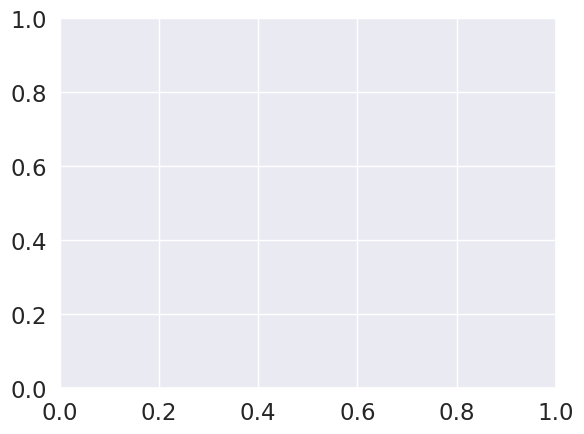

In [62]:
keys = ['CD8+ T-cell','CD4+ T-cell','NK cells PD-L1+']
for key in keys:
    plt.plot((x[1:]+x[:-1])/2,np.nanmedian(dic_pCR[key],axis = 0),label = key,ls = '--',lw = 0.7)
    q75, q25 = np.nanpercentile(dic_pCR[key], [75 ,25],axis = 0)
    plt.fill_between((x[1:]+x[:-1])/2,q75,q25,alpha = 0.5)

plt.xlabel('distance [$\mu m$]')
plt.title('$\\frac{P(X|\mathrm{Cancer B7}^-\mathrm{H4}^+)}{P(X)}$')
plt.legend(loc = 'lower right')
plt.tight_layout()
plt.figure()
for key in keys:
    plt.plot((x[1:]+x[:-1])/2,np.nanmedian(dic_nR[key],axis = 0),label = key,ls = '--',lw = 0.7)
    q75, q25 = np.nanpercentile(dic_nR[key], [75 ,25],axis = 0)
    plt.fill_between((x[1:]+x[:-1])/2,q75,q25,alpha = 0.5)


In [172]:
#labels and counts that are shared between all acquisitions
adata.obs.Pixie.value_counts()[adata.obs.Pixie.value_counts().index.isin(labels_list)]

Pixie
Cancer B7-H4+              142348
Neutrophil & Monocyte      110543
CD68+ MAC PD               100904
CD11b MAC + VEGF            70904
CD8+ T-cell                 63954
CD4+ T-cell                 59302
Monocyte CD16+              56863
NK cells PD-L1+             51308
Memory CD8 T-cell           48059
*B7-H4 - p53                46649
CD163+ MAC                  46435
NK & CD8 T-cell col+vim     35963
Cancer                      34442
Endothelial cells           29875
Naive B-cells               28211
Memory B-cell               24685
NK cells p53+               23737
EGFR                        20890
Fibroblasts                 20079
Fibrocytes                  17618
Name: count, dtype: int64

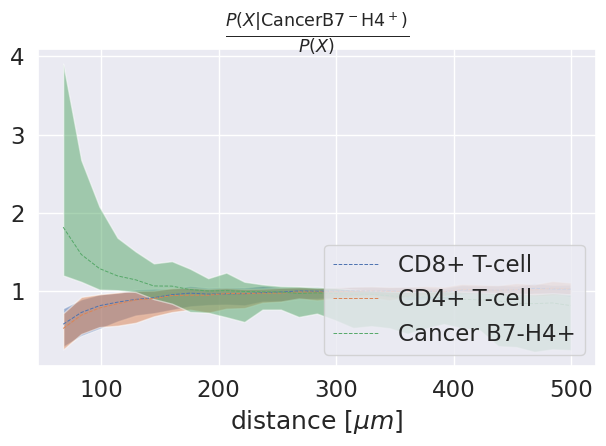

In [281]:
for key in ['CD8+ T-cell','CD4+ T-cell','Cancer B7-H4+']:
    plt.plot(x,np.nanmedian(dic[key],axis = 0),label = key,ls = '--',lw = 0.7)
    q75, q25 = np.nanpercentile(dic[key], [75 ,25],axis = 0)
    plt.fill_between(x,q75,q25,alpha = 0.5)

plt.xlabel('distance [$\mu m$]')
plt.title('$\\frac{P(X|\mathrm{Cancer B7}^-\mathrm{H4}^+)}{P(X)}$')
plt.legend(loc = 'lower right')
plt.tight_layout()
#plt.savefig(output_fig+'/spatial/co_occurrence_Tcells.png')

In [282]:
dic2 = defaultdict(list)
key2 = 'Fibroblasts' #'Cancer'


types_to_inspect = ['*B7-H4 - p53', 'CD11b MAC + VEGF', 'CD163+ MAC', 'CD4+ T-cell',
       'CD68+ MAC PD', 'CD8+ T-cell', 'Cancer', 'Cancer B7-H4+', 'EGFR',
       'Endothelial cells', 'Fibroblasts', 'Fibrocytes', 'Memory B-cell',
       'Memory CD8 T-cell', 'Monocyte CD16+', 'NK & CD8 T-cell col+vim',
       'NK cells PD-L1+', 'NK cells p53+', 'Naive B-cells',
       'Neutrophil & Monocyte']
for ID in  tqdm(adata.obs.acquisition_ID.unique()):
    sub_adata = adata[adata.obs.acquisition_ID==ID].copy()
    a = np.array(sub_adata.obs['Pixie'].cat.categories)#label list

    if ((key2 in a)& np.isin(types_to_inspect,a).any()): 
        #if there is at least a cell to inspect
        sq.gr.co_occurrence(sub_adata, cluster_key="Pixie",n_splits=1,interval=30)
        x = sub_adata.uns['Pixie_co_occurrence']['interval'][1:]
        cooccur = np.squeeze(sub_adata.uns['Pixie_co_occurrence']['occ'][np.arange(len(a))[a==key2]])
        for key in types_to_inspect:
            if (key in a):
                y = np.squeeze(cooccur[a ==key])
                dic2[key]+=[y]







  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.15s/]




  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.06s/]




  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.05/s]




  0

  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.42s/]




  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.00/s]




  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.87/s]




  0%|  

  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.20/s]




  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.06s/]




  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.17s/]




  0%|  

  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.39s/]




  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.86s/]




  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.65/s]




  0%|  

  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:07<00:00,  7.50s/]




  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.12s/]




  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.37s/]




  0%|  

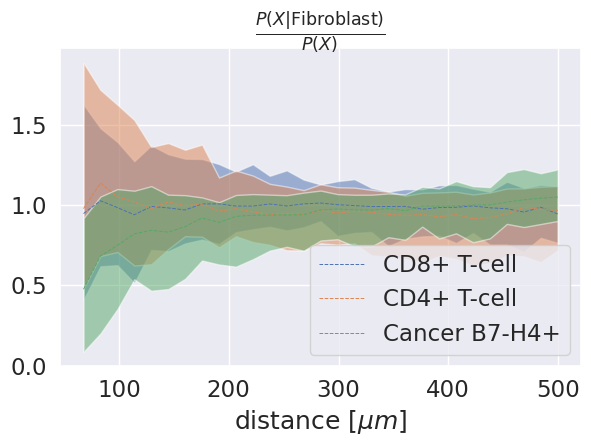

In [289]:
for key in ['CD8+ T-cell','CD4+ T-cell','Cancer B7-H4+']:
    plt.plot(x,np.nanmedian(dic2[key],axis = 0),label = key,ls = '--',lw = 0.7)
    q75, q25 = np.nanpercentile(dic2[key], [75 ,25],axis = 0)
    plt.fill_between(x,q75,q25,alpha = 0.5)

plt.xlabel('distance [$\mu m$]')
plt.title('$\\frac{P(X|\mathrm{Fibroblast})}{P(X)}$')
plt.legend(loc = 'lower right')
plt.tight_layout()
#plt.savefig(output_fig+'/spatial/co_occurrence_Tcells.png')

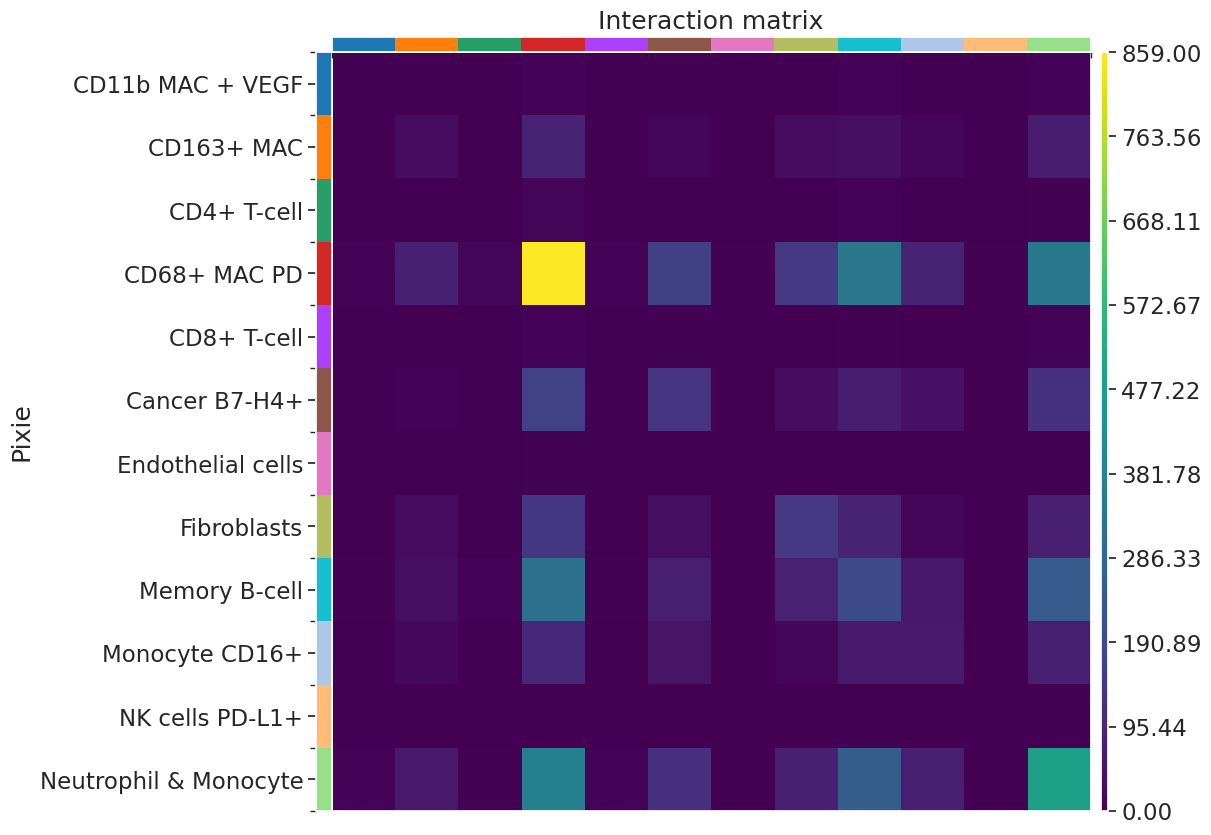

In [277]:
sq.gr.spatial_neighbors(sub_adata)

sq.gr.interaction_matrix(sub_adata, cluster_key="Pixie")
sq.pl.interaction_matrix(sub_adata, cluster_key="Pixie")

before treatment

In [171]:
dic = defaultdict(list)
for ID in ['Leap001_010', 'Leap001_009', 'Leap001_008']:
    sub_adata = adata[adata.obs.slice_ID==ID]
    a = np.array(sub_adata.obs['AnnoSpat'].cat.categories)#label list

    key0 = 'Naive CD8 T cells'
    key1 =  'Regulatory T cells'
    key2 = 'Naive B cells'
    if ((key0 in a)&((key1 in a) | (key2 in a))): 
        sq.gr.co_occurrence(sub_adata, cluster_key="AnnoSpat",n_splits=1)
        x = sub_adata.uns['AnnoSpat_co_occurrence']['interval'][1:]

        if (key1 in a):
            y1 = np.squeeze(np.squeeze(sub_adata.uns['AnnoSpat_co_occurrence']['occ'][np.arange(len(a))[a==key0]])[a ==key1])
            dic[key1]+=[y1]
        if (key2 in a):
            y2 = np.squeeze(np.squeeze(sub_adata.uns['AnnoSpat_co_occurrence']['occ'][np.arange(len(a))[a==key0]])[a == key2])
            dic[key2]+=[y2]

  0%|          | 0/1 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


  0%|          | 0/1 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


  0%|          | 0/1 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


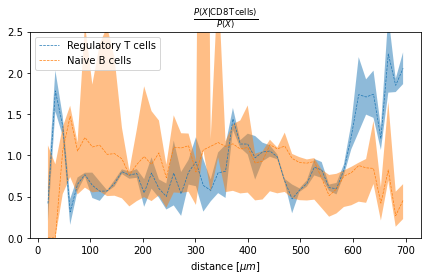

In [172]:
plt.plot(x,np.median(dic[key1],axis = 0),label = key1,ls = '--',lw = 0.7)
q75, q25 = np.percentile(dic[key1], [75 ,25],axis = 0)
plt.fill_between(x,q75,q25,alpha = 0.5)

plt.plot(x,np.median(dic[key2],axis = 0),label = key2,ls = '--',lw = 0.7)
q75, q25 = np.percentile(dic[key2], [75 ,25],axis = 0)
plt.fill_between(x,q75,q25,alpha = 0.5)
plt.xlabel('distance [$\mu m$]')
plt.title('$\\frac{P(X|\mathrm{CD8 \,T cells})}{P(X)}$')
plt.legend()
plt.tight_layout()
plt.ylim(0,2.5)
#plt.savefig(output_fig+'/co_occurrence_B_Tcells_before.png')

In [281]:
sq.gr.interaction_matrix(sub_adata, cluster_key="Pixie")

KeyError: "Spatial connectivity key `spatial_connectivities` not found in `adata.obsp`. Please run `squidpy.gr.spatial_neighbors(..., key_added='spatial')` first."

ERROR: Unable to fetch palette, reason: 'AnnoSpat_colors'. Using `None`.


<ipython-input-124-452c79bfe22b>:7: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


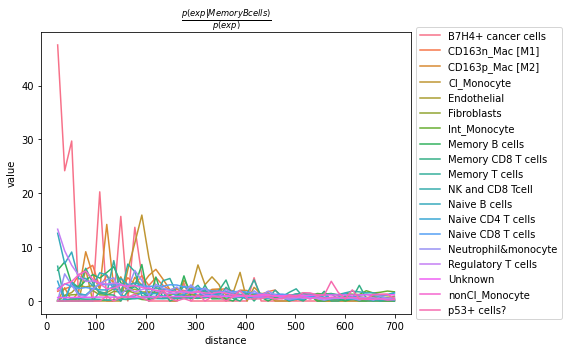

In [124]:
sq.pl.co_occurrence(
    sub_adata,
    cluster_key="AnnoSpat",
    clusters=['Memory B cells'],
    figsize=(8, 5),
)
plt.tight_layout()
#plt.savefig(output_fig+'/co_occurrence_all.png')

ERROR: Unable to fetch palette, reason: 'AnnoSpat_colors'. Using `None`.


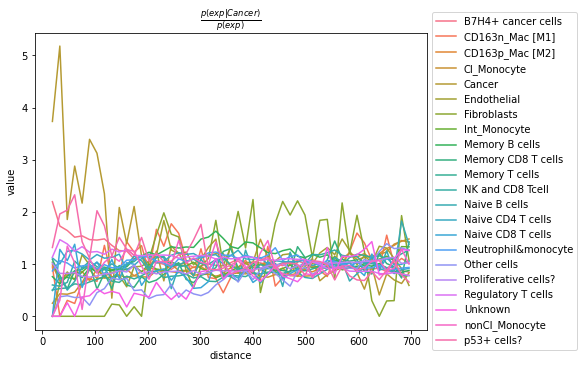

In [185]:
sq.pl.co_occurrence(
    ROI_1,
    cluster_key="AnnoSpat",
    clusters=['Cancer'],
    figsize=(8, 5),
)

In [21]:
cell_type_totals = pd.read_csv('../IMC_SegmentationResults/IMCCelltypeResults/CellTypeTotals.csv')
cell_type_totals.head()

,Image,CellType,Total,Density,Total_highProb,Density_highProb,Area_highProb,Max_probability_area,Max_probability_area_percentage
0,Leap001_ROI_001,Cancer,140.336744,0.000122,0.000000,0.000000,0.000000,0,0.000000
1,Leap001_ROI_001,CD163p_Mac..M2.,1726.340928,0.001505,31.445619,0.000027,0.000172,37,0.003226
2,Leap001_ROI_001,CD163n_Mac..M1.,6245.313083,0.005446,1.636302,0.000001,0.000013,4,0.000349
3,Leap001_ROI_001,Naive.CD4.T.cells,18.398982,0.000016,3.855173,0.000003,0.000022,7,0.000610
4,Leap001_ROI_001,Memory.T.cells,6.909340,0.000006,1.678131,0.000001,0.000010,2,0.000174


In [204]:
sc.pl.dotplot(adata, var_names = marker_list, groupby = groupby,return_fig=True)

source_file  ROI
Leap001_008  1      11285
Leap002_007  2       8471
Leap002_006  3       7998
Leap002_004  5       7486
Leap002_005  4       7418
Leap002_003  7       6399
Leap001_009  2       4741
Leap001_010  3       4233
dtype: int64

In [81]:
!conda remove pandas

Solving environment: failed

PackagesNotFoundError: The following packages are missing from the target environment:
  - pandas




In [10]:
adata.obsm['spatial'].shape

(3823755, 2)